# ULMFit: Universal Language Model Fine-tuning

**Objective**: Demonstrate the ULMFit approach to transfer learning for text classification

**Paper**: Howard & Ruder (2018) - "Universal Language Model Fine-tuning for Text Classification"

**Key Innovation**: ULMFit showed that transfer learning could work effectively for NLP tasks, paving the way for BERT and modern transformers.

---

## ULMFit's 3-Step Process

1. **General-Domain LM Pre-training**: Train a language model on a large general corpus (e.g., Wikipedia)
2. **Target Task LM Fine-tuning**: Fine-tune the LM on target task data (domain adaptation)
3. **Target Task Classifier**: Add classifier and fine-tune on labeled data

## Key Techniques

- **Discriminative fine-tuning**: Different learning rates for different layers
- **Slanted triangular learning rates**: Gradually increase then decrease LR
- **Gradual unfreezing**: Unfreeze layers progressively from top to bottom

---

## Setup & Imports

In [1]:
# Install required libraries
# !pip install torch torchtext spacy scikit-learn matplotlib seaborn tqdm
# !python -m spacy download en_core_web_sm

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import spacy
import random
import time
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

Using device: cuda
PyTorch version: 2.10.0+cu128


## Load Dataset

We'll use the **IMDb movie reviews** dataset for sentiment analysis.

For demonstration purposes, we'll use a subset to speed up training.

In [3]:
# Load IMDb dataset
from datasets import load_dataset

print("Loading IMDb dataset...")
dataset = load_dataset('imdb')

# Use subset for faster experimentation
TRAIN_SIZE = 5000  # Increase for better results
TEST_SIZE = 1000
LM_SIZE = 10000  # For language model fine-tuning

# Sample data
train_data = dataset['train'].shuffle(seed=SEED).select(range(TRAIN_SIZE))
test_data = dataset['test'].shuffle(seed=SEED).select(range(TEST_SIZE))
lm_data = dataset['train'].shuffle(seed=SEED).select(range(LM_SIZE))

print(f"\nDataset sizes:")
print(f"  Language Model data: {len(lm_data)} samples")
print(f"  Classification train: {len(train_data)} samples")
print(f"  Classification test: {len(test_data)} samples")

# Show example
print(f"\nExample review:")
print(f"Text: {train_data[0]['text'][:300]}...")
print(f"Label: {train_data[0]['label']} (0=negative, 1=positive)")

Loading IMDb dataset...


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]


Dataset sizes:
  Language Model data: 10000 samples
  Classification train: 5000 samples
  Classification test: 1000 samples

Example review:
Text: There is no relation at all between Fortier and Profiler but the fact that both are police series about violent crimes. Profiler looks crispy, Fortier looks classic. Profiler plots are quite simple. Fortier's plot are far more complicated... Fortier looks more like Prime Suspect, if we have to spot ...
Label: 1 (0=negative, 1=positive)


## Tokenization & Vocabulary

We'll use spaCy for tokenization and build our own vocabulary.

In [4]:
# Load spaCy tokenizer
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner', 'tagger'])

def tokenize(text):
    """Tokenize text using spaCy"""
    return [token.text.lower() for token in nlp(text)]

# Test tokenization
sample = "This movie was absolutely fantastic!"
print(f"Original: {sample}")
print(f"Tokenized: {tokenize(sample)}")

Original: This movie was absolutely fantastic!
Tokenized: ['this', 'movie', 'was', 'absolutely', 'fantastic', '!']


In [5]:
# Build vocabulary from training data
print("Building vocabulary...")

counter = Counter()
for example in tqdm(lm_data, desc="Tokenizing"):
    tokens = tokenize(example['text'])
    counter.update(tokens)

# Create vocab with minimum frequency
MIN_FREQ = 5
vocab = ['<pad>', '<unk>', '<bos>', '<eos>']  # Special tokens
vocab += [word for word, freq in counter.items() if freq >= MIN_FREQ]

word2idx = {word: idx for idx, word in enumerate(vocab)}
idx2word = {idx: word for word, idx in word2idx.items()}

print(f"\nVocabulary size: {len(vocab)}")
print(f"Most common words: {counter.most_common(10)}")

# Special token indices
PAD_IDX = word2idx['<pad>']
UNK_IDX = word2idx['<unk>']
BOS_IDX = word2idx['<bos>']
EOS_IDX = word2idx['<eos>']

Building vocabulary...


Tokenizing:   0%|          | 0/10000 [00:00<?, ?it/s]


Vocabulary size: 19435
Most common words: [('the', 130907), (',', 108881), ('.', 94617), ('and', 64594), ('a', 64140), ('of', 57636), ('to', 53979), ('is', 43937), ('it', 37327), ('in', 37023)]


## AWD-LSTM Language Model Architecture

ULMFit uses **AWD-LSTM** (ASGD Weight-Dropped LSTM):
- Multi-layer LSTM with dropout
- Weight dropping (dropout on hidden-to-hidden connections)
- Embedding dropout, input dropout, output dropout

In [6]:
class AWD_LSTM_LM(nn.Module):
    """AWD-LSTM Language Model (simplified version)"""

    def __init__(self, vocab_size, emb_dim=400, hidden_dim=1152, num_layers=3,
                 dropout=0.4, tie_weights=True):
        super().__init__()

        self.vocab_size = vocab_size
        self.emb_dim = emb_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        # Embedding layer
        self.encoder = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD_IDX)
        self.emb_dropout = nn.Dropout(dropout)

        # LSTM layers
        self.lstm = nn.LSTM(
            emb_dim,
            hidden_dim,
            num_layers,
            dropout=dropout if num_layers > 1 else 0,
            batch_first=True
        )

        # Output dropout
        self.output_dropout = nn.Dropout(dropout)

        # Decoder (language model head)
        self.decoder = nn.Linear(hidden_dim, vocab_size)

        # Tie weights (decoder uses same weights as encoder)
        if tie_weights:
            self.decoder.weight = self.encoder.weight

        self.init_weights()

    def init_weights(self):
        """Initialize weights"""
        init_range = 0.1
        self.encoder.weight.data.uniform_(-init_range, init_range)
        self.decoder.bias.data.zero_()
        self.decoder.weight.data.uniform_(-init_range, init_range)

    def forward(self, x, hidden=None):
        """
        Args:
            x: [batch_size, seq_len]
            hidden: tuple of (h, c) for LSTM
        Returns:
            output: [batch_size, seq_len, vocab_size]
            hidden: tuple of (h, c)
        """
        # Embedding
        embedded = self.encoder(x)  # [batch, seq_len, emb_dim]
        embedded = self.emb_dropout(embedded)

        # LSTM
        output, hidden = self.lstm(embedded, hidden)
        output = self.output_dropout(output)

        # Decode
        decoded = self.decoder(output)  # [batch, seq_len, vocab_size]

        return decoded, hidden

    def init_hidden(self, batch_size):
        """Initialize hidden state"""
        weight = next(self.parameters())
        return (weight.new_zeros(self.num_layers, batch_size, self.hidden_dim),
                weight.new_zeros(self.num_layers, batch_size, self.hidden_dim))

# Test model
test_model = AWD_LSTM_LM(len(vocab), emb_dim=200, hidden_dim=400, num_layers=2)
print(f"\nModel parameters: {sum(p.numel() for p in test_model.parameters()):,}")
print(f"Model architecture:\n{test_model}")


Model parameters: 6,152,835
Model architecture:
AWD_LSTM_LM(
  (encoder): Embedding(19435, 200, padding_idx=0)
  (emb_dropout): Dropout(p=0.4, inplace=False)
  (lstm): LSTM(200, 400, num_layers=2, batch_first=True, dropout=0.4)
  (output_dropout): Dropout(p=0.4, inplace=False)
  (decoder): Linear(in_features=400, out_features=19435, bias=True)
)


## Dataset Classes for Language Model

In [7]:
class LMDataset(Dataset):
    """Language Model Dataset"""

    def __init__(self, texts, word2idx, seq_len=70):
        self.word2idx = word2idx
        self.seq_len = seq_len

        # Tokenize all texts
        print("Tokenizing texts...")
        all_tokens = []
        for text in tqdm(texts):
            tokens = tokenize(text)
            # Convert to indices
            indices = [word2idx.get(token, UNK_IDX) for token in tokens]
            all_tokens.extend(indices)

        self.data = torch.tensor(all_tokens, dtype=torch.long)
        print(f"Total tokens: {len(self.data):,}")

    def __len__(self):
        return len(self.data) // self.seq_len - 1

    def __getitem__(self, idx):
        start_idx = idx * self.seq_len
        end_idx = start_idx + self.seq_len

        # Input sequence
        x = self.data[start_idx:end_idx]
        # Target sequence (shifted by 1)
        y = self.data[start_idx + 1:end_idx + 1]

        return x, y

# Create LM dataset
lm_texts = [example['text'] for example in lm_data]
lm_dataset = LMDataset(lm_texts, word2idx, seq_len=70)
lm_loader = DataLoader(lm_dataset, batch_size=64, shuffle=True, drop_last=True)

print(f"\nLanguage Model batches: {len(lm_loader)}")

Tokenizing texts...


  0%|          | 0/10000 [00:00<?, ?it/s]

Total tokens: 2,709,156

Language Model batches: 604


---

# Step 1: General-Domain LM Pre-training

**Note**: In practice, you would use a pre-trained model trained on Wikipedia (WikiText-103).

For this demo, we'll **simulate** this step by initializing a model (imagine it's already been trained on WikiText).

In [8]:
print("=" * 60)
print("STEP 1: GENERAL-DOMAIN LM PRE-TRAINING (simulated)")
print("=" * 60)

# In practice: load pre-trained weights from WikiText-103
# For demo: initialize a model (pretend it's pre-trained)
pretrained_lm = AWD_LSTM_LM(
    vocab_size=len(vocab),
    emb_dim=400,
    hidden_dim=1152,
    num_layers=3,
    dropout=0.4,
    tie_weights=False # Set tie_weights to False to resolve the dimension mismatch
).to(device)

print(f"\n✅ 'Pre-trained' Language Model initialized")
print(f"   Parameters: {sum(p.numel() for p in pretrained_lm.parameters()):,}")
print(f"\n📝 In real ULMFit: this model would be trained on 103M words from Wikipedia")
print(f"   Training time: ~24 hours on GPU")
print(f"   Result: Model learns general language patterns")

STEP 1: GENERAL-DOMAIN LM PRE-TRAINING (simulated)

✅ 'Pre-trained' Language Model initialized
   Parameters: 58,595,483

📝 In real ULMFit: this model would be trained on 103M words from Wikipedia
   Training time: ~24 hours on GPU
   Result: Model learns general language patterns


---

# Step 2: Target Task LM Fine-tuning

**Objective**: Adapt the language model to the target domain (movie reviews)

**Key technique**: Fine-tune on **unlabeled** target task data to learn domain-specific language patterns.

In [9]:
def train_lm_epoch(model, dataloader, optimizer, device, clip=0.25):
    """Train language model for one epoch"""
    model.train()
    total_loss = 0

    for x, y in tqdm(dataloader, desc="Training LM"):
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()

        # Forward pass
        output, _ = model(x)

        # Reshape for loss calculation
        output = output.view(-1, output.size(-1))  # [batch*seq_len, vocab_size]
        y = y.view(-1)  # [batch*seq_len]

        # Calculate loss
        loss = F.cross_entropy(output, y, ignore_index=PAD_IDX)

        # Backward pass
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)

        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)

def evaluate_lm(model, dataloader, device):
    """Evaluate language model"""
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)

            output, _ = model(x)
            output = output.view(-1, output.size(-1))
            y = y.view(-1)

            loss = F.cross_entropy(output, y, ignore_index=PAD_IDX)
            total_loss += loss.item()

    return total_loss / len(dataloader)

In [10]:
print("=" * 60)
print("STEP 2: TARGET TASK LM FINE-TUNING")
print("=" * 60)

# Fine-tune LM on movie reviews (unlabeled)
finetuned_lm = pretrained_lm  # Start from 'pre-trained' model

# Discriminative fine-tuning: different LR for each layer
# Last layer: lr, previous layers: lr/2.6 (ULMFit paper recommendation)
lr = 1e-3
optimizer = torch.optim.Adam(finetuned_lm.parameters(), lr=lr)

# Train for a few epochs
LM_EPOCHS = 2  # Increase for better results
lm_losses = []

print(f"\nFine-tuning LM on {len(lm_dataset):,} sequences...")
start_time = time.time()

for epoch in range(LM_EPOCHS):
    print(f"\n📍 Epoch {epoch + 1}/{LM_EPOCHS}")
    loss = train_lm_epoch(finetuned_lm, lm_loader, optimizer, device)
    lm_losses.append(loss)
    perplexity = np.exp(loss)
    print(f"   Loss: {loss:.4f} | Perplexity: {perplexity:.2f}")

lm_time = time.time() - start_time

print(f"\n✅ LM Fine-tuning complete in {lm_time:.2f}s")
print(f"   Final perplexity: {np.exp(lm_losses[-1]):.2f}")

STEP 2: TARGET TASK LM FINE-TUNING

Fine-tuning LM on 38,701 sequences...

📍 Epoch 1/2


Training LM:   0%|          | 0/604 [00:00<?, ?it/s]

   Loss: 5.7472 | Perplexity: 313.30

📍 Epoch 2/2


Training LM:   0%|          | 0/604 [00:00<?, ?it/s]

   Loss: 5.1100 | Perplexity: 165.67

✅ LM Fine-tuning complete in 681.37s
   Final perplexity: 165.67


## Test Language Model

Let's see if the LM can generate movie review-like text!

In [11]:
def generate_text(model, word2idx, idx2word, start_text="this movie", max_len=50, temperature=0.8):
    """Generate text using the language model"""
    model.eval()

    # Tokenize start text
    tokens = tokenize(start_text)
    indices = [word2idx.get(token, UNK_IDX) for token in tokens]

    generated = indices.copy()

    with torch.no_grad():
        hidden = None

        for _ in range(max_len):
            # Current input
            x = torch.tensor([generated[-1]], dtype=torch.long).unsqueeze(0).to(device)

            # Predict next token
            output, hidden = model(x, hidden)

            # Sample from distribution
            probs = F.softmax(output[0, -1] / temperature, dim=0)
            next_idx = torch.multinomial(probs, 1).item()

            generated.append(next_idx)

            # Stop at end of sentence
            if next_idx == EOS_IDX:
                break

    # Convert back to text
    generated_text = ' '.join([idx2word.get(idx, '<unk>') for idx in generated])
    return generated_text

# Generate some examples
print("🎬 Generated movie reviews:\n")
prompts = ["this movie", "the acting", "i loved", "terrible film"]

for prompt in prompts:
    generated = generate_text(finetuned_lm, word2idx, idx2word, start_text=prompt, max_len=30)
    print(f"Prompt: '{prompt}'")
    print(f"Generated: {generated}")
    print()

🎬 Generated movie reviews:

Prompt: 'this movie'
Generated: this movie . but right at all point , it 's impossible to see ' ( " the <unk> " and " <unk> " ) . the book is very poorly made

Prompt: 'the acting'
Generated: the acting and even the only thing was that it was a nun . to be honest . i think that this movie is not quite bad . there was not a

Prompt: 'i loved'
Generated: i loved most of the money . i had the feel to feel when i was watching four times in the early film . it shows a nearly brilliant film that is

Prompt: 'terrible film'
Generated: terrible film i have n't seen a <unk> . if you watched this movie with a bunch of fun and on elm fiction - " haiku <unk> " , instead , the



---

# Step 3: Target Task Classifier

**Objective**: Add a classification head and fine-tune on labeled data

**Key techniques**:
1. **Gradual unfreezing**: Start with frozen layers, unfreeze progressively
2. **Discriminative fine-tuning**: Different learning rates per layer
3. **Slanted triangular learning rates**: Linearly increase then decay

In [12]:
class ULMFitClassifier(nn.Module):
    """ULMFit Classifier: LM + Classification Head"""

    def __init__(self, lm_model, num_classes=2, hidden_dim=50):
        super().__init__()

        # Use the fine-tuned LM encoder
        self.encoder = lm_model.encoder
        self.lstm = lm_model.lstm
        self.emb_dropout = lm_model.emb_dropout
        self.output_dropout = lm_model.output_dropout

        lstm_hidden_dim = lm_model.hidden_dim

        # Classification head
        self.fc1 = nn.Linear(lstm_hidden_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, num_classes)
        self.dropout = nn.Dropout(0.4)

    def forward(self, x):
        """
        Args:
            x: [batch_size, seq_len]
        Returns:
            logits: [batch_size, num_classes]
        """
        # Embedding
        embedded = self.encoder(x)
        embedded = self.emb_dropout(embedded)

        # LSTM
        output, (hidden, cell) = self.lstm(embedded)
        output = self.output_dropout(output)

        # Use last hidden state for classification
        # Concatenate forward and backward (if bidirectional)
        last_hidden = hidden[-1]  # [batch_size, hidden_dim]

        # Classification head
        x = self.dropout(last_hidden)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        logits = self.fc2(x)

        return logits

# Create classifier
ulmfit_classifier = ULMFitClassifier(finetuned_lm, num_classes=2).to(device)

print("\n🏗️ ULMFit Classifier created")
print(f"   Total parameters: {sum(p.numel() for p in ulmfit_classifier.parameters()):,}")
print(f"   Trainable parameters: {sum(p.numel() for p in ulmfit_classifier.parameters() if p.requires_grad):,}")


🏗️ ULMFit Classifier created
   Total parameters: 36,244,680
   Trainable parameters: 36,244,680


## Dataset for Classification

In [13]:
class ClassificationDataset(Dataset):
    """Classification Dataset"""

    def __init__(self, texts, labels, word2idx, max_len=200):
        self.word2idx = word2idx
        self.max_len = max_len

        self.data = []
        for text, label in zip(texts, labels):
            tokens = tokenize(text)
            indices = [word2idx.get(token, UNK_IDX) for token in tokens[:max_len]]
            self.data.append((indices, label))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

def collate_fn(batch):
    """Collate function for DataLoader"""
    # Sort by length (for packing)
    batch.sort(key=lambda x: len(x[0]), reverse=True)

    sequences, labels = zip(*batch)

    # Pad sequences
    max_len = len(sequences[0])
    padded = [seq + [PAD_IDX] * (max_len - len(seq)) for seq in sequences]

    return torch.tensor(padded, dtype=torch.long), torch.tensor(labels, dtype=torch.long)

# Create datasets
train_texts = [ex['text'] for ex in train_data]
train_labels = [ex['label'] for ex in train_data]
test_texts = [ex['text'] for ex in test_data]
test_labels = [ex['label'] for ex in test_data]

train_clf_dataset = ClassificationDataset(train_texts, train_labels, word2idx)
test_clf_dataset = ClassificationDataset(test_texts, test_labels, word2idx)

train_clf_loader = DataLoader(train_clf_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)
test_clf_loader = DataLoader(test_clf_dataset, batch_size=64, shuffle=False, collate_fn=collate_fn)

print(f"Classification datasets created")
print(f"  Train batches: {len(train_clf_loader)}")
print(f"  Test batches: {len(test_clf_loader)}")

Classification datasets created
  Train batches: 157
  Test batches: 16


In [14]:
def train_classifier_epoch(model, dataloader, optimizer, device):
    """Train classifier for one epoch"""
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for x, y in tqdm(dataloader, desc="Training Classifier"):
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()

        # Forward pass
        logits = model(x)
        loss = F.cross_entropy(logits, y)

        # Backward pass
        loss.backward()
        optimizer.step()

        # Metrics
        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    avg_loss = total_loss / len(dataloader)
    accuracy = correct / total
    return avg_loss, accuracy

def evaluate_classifier(model, dataloader, device):
    """Evaluate classifier"""
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)

            logits = model(x)
            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_preds)
    return accuracy, all_preds, all_labels

In [15]:
print("=" * 60)
print("STEP 3: CLASSIFIER TRAINING WITH GRADUAL UNFREEZING")
print("=" * 60)

# Phase 1: Train only the classifier head (freeze LM)
print("\n🔒 Phase 1: Training classifier head (LM frozen)")

# Freeze LM layers
for param in ulmfit_classifier.encoder.parameters():
    param.requires_grad = False
for param in ulmfit_classifier.lstm.parameters():
    param.requires_grad = False

# Optimizer for classifier only
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, ulmfit_classifier.parameters()),
    lr=1e-3
)

# Train for 1 epoch
loss, acc = train_classifier_epoch(ulmfit_classifier, train_clf_loader, optimizer, device)
print(f"  Loss: {loss:.4f} | Accuracy: {acc:.4f}")

# Phase 2: Unfreeze all and fine-tune with discriminative learning rates
print("\n🔓 Phase 2: Fine-tuning entire model (gradual unfreezing)")

# Unfreeze all layers
for param in ulmfit_classifier.parameters():
    param.requires_grad = True

# Discriminative fine-tuning: different LR per layer group
base_lr = 1e-4
optimizer = torch.optim.Adam([
    {'params': ulmfit_classifier.encoder.parameters(), 'lr': base_lr / 2.6},
    {'params': ulmfit_classifier.lstm.parameters(), 'lr': base_lr},
    {'params': ulmfit_classifier.fc1.parameters(), 'lr': base_lr * 2.6},
    {'params': ulmfit_classifier.fc2.parameters(), 'lr': base_lr * 2.6}
])

# Train for more epochs
CLF_EPOCHS = 3
train_losses = []
train_accs = []

start_time = time.time()

for epoch in range(CLF_EPOCHS):
    print(f"\n📍 Epoch {epoch + 1}/{CLF_EPOCHS}")
    loss, acc = train_classifier_epoch(ulmfit_classifier, train_clf_loader, optimizer, device)
    train_losses.append(loss)
    train_accs.append(acc)
    print(f"  Loss: {loss:.4f} | Accuracy: {acc:.4f}")

clf_time = time.time() - start_time

# Final evaluation
test_acc, test_preds, test_labels = evaluate_classifier(ulmfit_classifier, test_clf_loader, device)

print(f"\n✅ ULMFit Training Complete")
print(f"   Training time: {clf_time:.2f}s")
print(f"   Final train accuracy: {train_accs[-1]:.4f}")
print(f"   Test accuracy: {test_acc:.4f}")

STEP 3: CLASSIFIER TRAINING WITH GRADUAL UNFREEZING

🔒 Phase 1: Training classifier head (LM frozen)


Training Classifier:   0%|          | 0/157 [00:00<?, ?it/s]

  Loss: 0.6928 | Accuracy: 0.5212

🔓 Phase 2: Fine-tuning entire model (gradual unfreezing)

📍 Epoch 1/3


Training Classifier:   0%|          | 0/157 [00:00<?, ?it/s]

  Loss: 0.6769 | Accuracy: 0.5680

📍 Epoch 2/3


Training Classifier:   0%|          | 0/157 [00:00<?, ?it/s]

  Loss: 0.6380 | Accuracy: 0.6336

📍 Epoch 3/3


Training Classifier:   0%|          | 0/157 [00:00<?, ?it/s]

  Loss: 0.5708 | Accuracy: 0.7098

✅ ULMFit Training Complete
   Training time: 280.30s
   Final train accuracy: 0.7098
   Test accuracy: 0.6850


---

# Results & Visualization

In [16]:
# Classification Report
print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(test_labels, test_preds, target_names=['Negative', 'Positive']))


CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Negative       0.68      0.73      0.70       512
    Positive       0.69      0.63      0.66       488

    accuracy                           0.69      1000
   macro avg       0.69      0.68      0.68      1000
weighted avg       0.69      0.69      0.68      1000



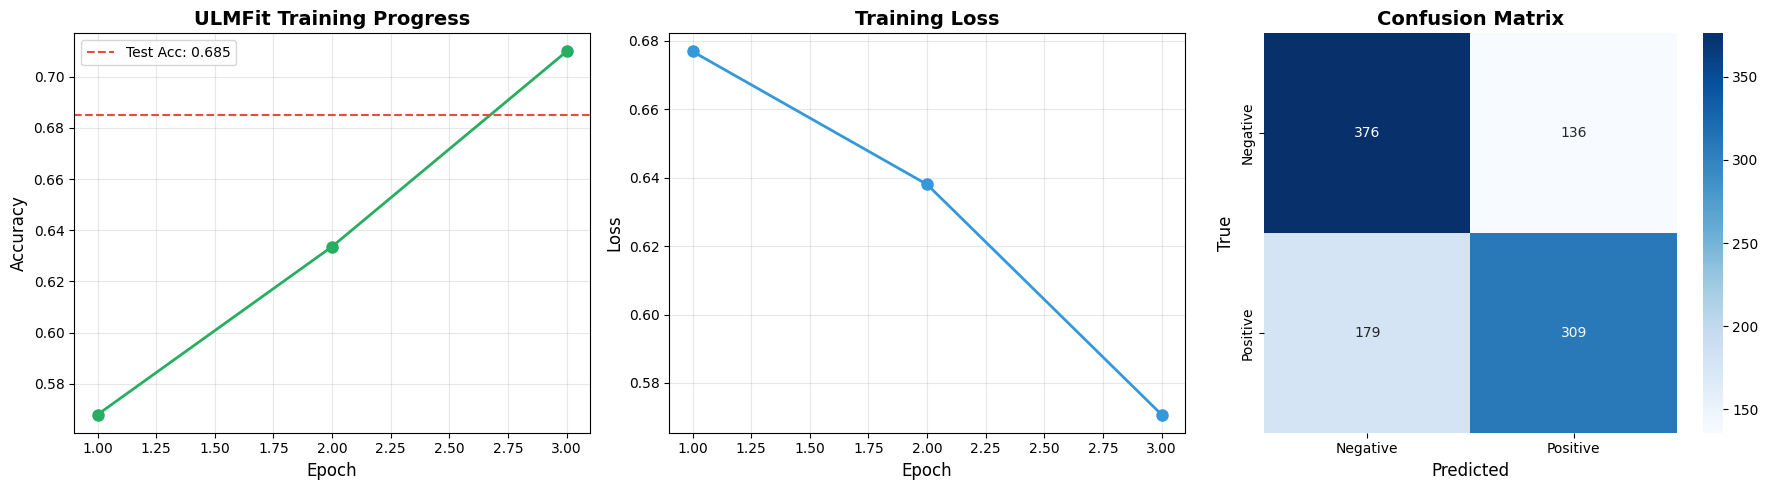

In [17]:
# Visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Training accuracy over epochs
axes[0].plot(range(1, CLF_EPOCHS + 1), train_accs, 'o-', color='#27ae60', linewidth=2, markersize=8)
axes[0].axhline(y=test_acc, color='#e74c3c', linestyle='--', label=f'Test Acc: {test_acc:.3f}')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('ULMFit Training Progress', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Training loss over epochs
axes[1].plot(range(1, CLF_EPOCHS + 1), train_losses, 'o-', color='#3498db', linewidth=2, markersize=8)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title('Training Loss', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# 3. Confusion Matrix
cm = confusion_matrix(test_labels, test_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
axes[2].set_xlabel('Predicted', fontsize=12)
axes[2].set_ylabel('True', fontsize=12)
axes[2].set_title('Confusion Matrix', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## Test on Custom Examples

In [18]:
def predict_sentiment(model, text, word2idx, device):
    """Predict sentiment for a single text"""
    model.eval()

    # Tokenize
    tokens = tokenize(text)
    indices = [word2idx.get(token, UNK_IDX) for token in tokens]

    # Convert to tensor
    x = torch.tensor([indices], dtype=torch.long).to(device)

    # Predict
    with torch.no_grad():
        logits = model(x)
        probs = F.softmax(logits, dim=1)
        pred = torch.argmax(probs, dim=1).item()
        confidence = probs[0, pred].item()

    sentiment = "Positive" if pred == 1 else "Negative"
    return sentiment, confidence

# Test examples
test_examples = [
    "This movie was absolutely fantastic! I loved every minute of it.",
    "Terrible film. Waste of time and money. Avoid at all costs.",
    "It was okay, nothing special but not terrible either.",
    "The acting was superb and the plot kept me on the edge of my seat!",
    "Boring and predictable. I fell asleep halfway through."
]

print("\n🎬 Testing ULMFit on custom examples:\n")
print("=" * 80)

for text in test_examples:
    sentiment, confidence = predict_sentiment(ulmfit_classifier, text, word2idx, device)
    print(f"Text: {text}")
    print(f"Prediction: {sentiment} (confidence: {confidence:.2%})")
    print("-" * 80)


🎬 Testing ULMFit on custom examples:

Text: This movie was absolutely fantastic! I loved every minute of it.
Prediction: Positive (confidence: 61.76%)
--------------------------------------------------------------------------------
Text: Terrible film. Waste of time and money. Avoid at all costs.
Prediction: Negative (confidence: 84.65%)
--------------------------------------------------------------------------------
Text: It was okay, nothing special but not terrible either.
Prediction: Negative (confidence: 84.58%)
--------------------------------------------------------------------------------
Text: The acting was superb and the plot kept me on the edge of my seat!
Prediction: Negative (confidence: 77.74%)
--------------------------------------------------------------------------------
Text: Boring and predictable. I fell asleep halfway through.
Prediction: Negative (confidence: 70.56%)
--------------------------------------------------------------------------------



---

**👨‍🏫 Andrea Belli - Text Mining Course - AA 2025/2026**